<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Computer-Vision/blob/main/Practicals/CR_Pract_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV"

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9400 - loss: 0.1967 - val_accuracy: 0.9837 - val_loss: 0.0556
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9818 - loss: 0.0579 - val_accuracy: 0.9868 - val_loss: 0.0447
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.9876 - loss: 0.0405 - val_accuracy: 0.9857 - val_loss: 0.0493
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9899 - loss: 0.0305 - val_accuracy: 0.9893 - val_loss: 0.0390
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9883 - val_loss: 0.0402
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9873 - loss: 0.0391
Test accuracy: 0.9873
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


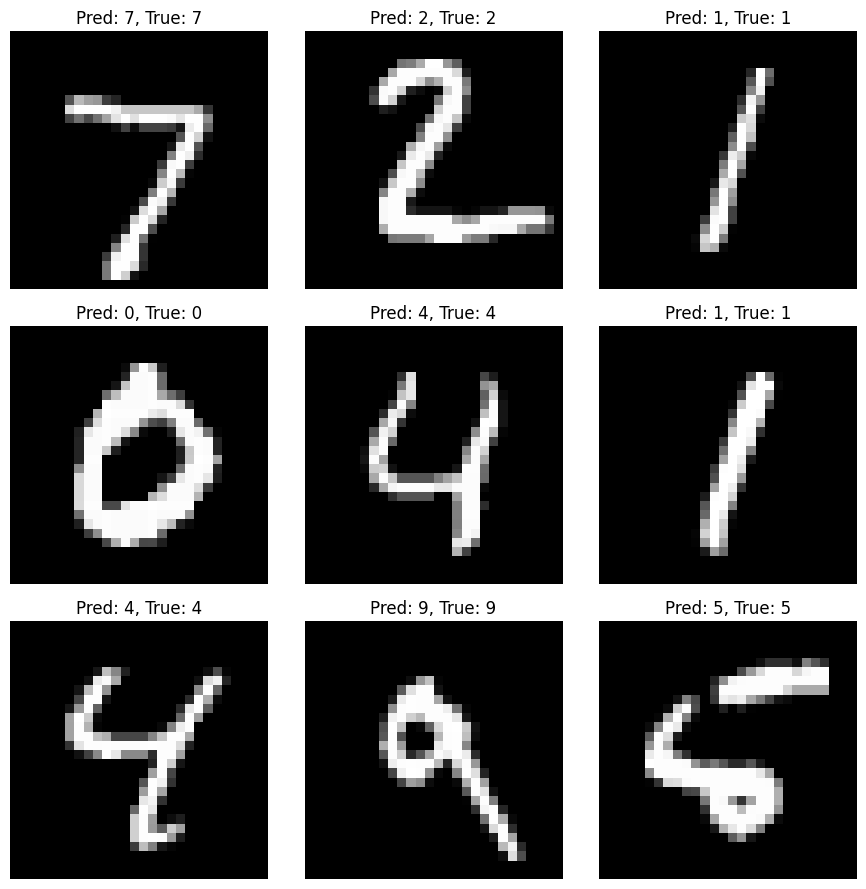

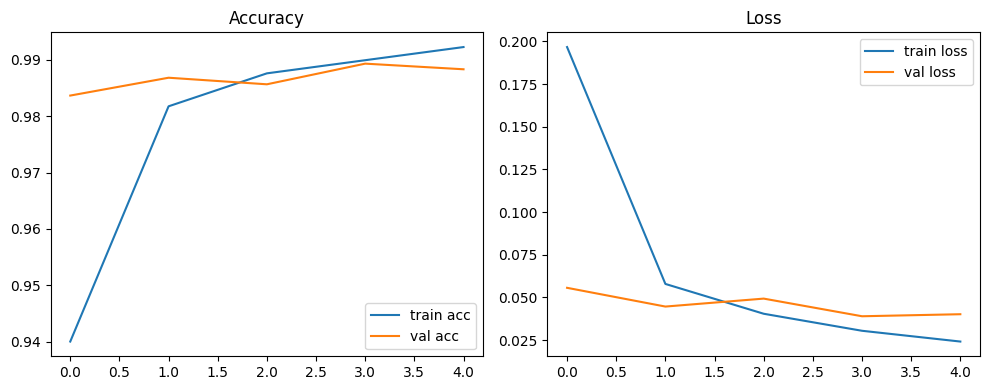

In [ ]:
# TensorFlow/Keras is pre-installed in Google Colab - no pip install needed there

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Step 1: Load the MNIST dataset (built into Keras - downloads automatically the first time)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print('Training images:', x_train.shape)
print('Test images:', x_test.shape)

# Step 2: Normalize pixel values to [0, 1] and add a channel dimension for the CNN
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Step 3: Build a simple CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Step 4: Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=64,
                     validation_split=0.1)

# Step 5: Evaluate on the (unseen) test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

# Step 6: Visualize a few predictions
predictions = model.predict(x_test[:9])
plt.figure(figsize=(9, 9))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f'Pred: {predictions[i].argmax()}, True: {y_test[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Step 7: Plot training accuracy / loss curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(), plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(), plt.title('Loss')
plt.tight_layout()
plt.show()

